# Transformer

In [1]:
import os
import numpy as np
from matplotlib import pyplot as plt
from functools import partial

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils.rnn import pad_sequence  # http://pytorch.org/docs/stable/generated/torch.nn.utils.rnn.pad_sequence.html
from torchsummary import summary

import icecube as ic
import transformer as tr
import helper as dl

In [2]:
# If the kernel is not restarted, packages are not reloaded by default
# This is to make sure the changes in the python scripts are loaded
import importlib

importlib.reload(ic)
importlib.reload(tr)
importlib.reload(dl);

### File paths and flags

In [3]:
DATA_PATH = "../datasets/icecube"
PLOT_PATH = "/mnt/Datos/LaTeX/deep-learning/ex8/figures"
MODEL_PATH = "models"

if not os.path.exists(DATA_PATH):
    raise Exception("Data folder does not exist")
if not os.path.exists(PLOT_PATH):
    raise Exception("Plots folder does not exist")
if not os.path.exists(MODEL_PATH):
    raise Exception("Model folder does not exist")

In [4]:
# Flags
TRAIN = False # Set to False to load a pre-trained model and skip training
SAVE_MODEL = True
SAVE_PLOTS = True

# Model name
SAVE_MODEL_NAME = "icecube-transformer.pth"
LOAD_MODEL_NAME = "icecube-transformer3.pth"

# Plot names
if not SAVE_PLOTS:
    PLOT_PATH = None

### Loading data

In [5]:
# Load the data
train_dataset, val_dataset, test_dataset = ic.load_icecube_data(DATA_PATH)

### Hyperparameter selection

In [6]:
# General hyperparameters
learning_rate = 1e-4
batch_size = 32
num_epochs = 40
patience = 5 # Training loop with early stopping, if the validation loss does not improve for 'patience' epochs

# GNN hyperparameters. We use a dictionary to save them together with the model
model_hyperparams = {
        'd_model': 128, 
        'nhead': 16, 
        'dim_feedforward': 1024, 
        'dropout': 0.02, 
        'nlayers': 8,
    }

### Prepare data por training

In [7]:
# Normalize the labels
train_dataset_norm, [means, stds] = ic.normalize_data(train_dataset)
val_dataset_norm, _ = ic.normalize_data(val_dataset)
test_dataset_norm, _ = ic.normalize_data(test_dataset)

# Create the dataloaders
train_loader, val_loader, test_loader = tr.create_dataloaders(train_dataset_norm, val_dataset_norm, test_dataset_norm, batch_size=batch_size)

### Definition of the model and the loss function

In [8]:
class TransformerEncoder(nn.Module):
    def __init__(self, d_model: int, nhead: int, dim_feedforward: int, dropout: float, nlayers: int) -> None:
        super().__init__()

        # Hint: define the input embedding layer
        self.input_embedding = nn.Linear(3, d_model, bias=False)

        encoder_layer = nn.TransformerEncoderLayer(  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoderLayer.html
            d_model = d_model,
            nhead = nhead,
            dim_feedforward = dim_feedforward,
            activation = "relu",
            batch_first = True,
            norm_first = True,
            dropout = dropout
        )

        self.encoder = nn.TransformerEncoder(
                    encoder_layer,
                    num_layers = nlayers,
                    norm = nn.LayerNorm(d_model),
                    enable_nested_tensor = False # not compatible with norm_first=True
                )  # https://pytorch.org/docs/stable/generated/torch.nn.TransformerEncoder.html

        # Hint: define the output projection layer
        self.output_projection = nn.Linear(d_model, 2)

    def forward(self, data: tuple[torch.Tensor, list[int]]) -> torch.Tensor:
        """
        Args:
            data: list of (src tensor, lengths)
        Returns:
            Tensor of shape (batch, output_dim)
        """

        src, lengths = data

        # F: input_dim, number of features (time, x, y)
        # N: number of hits
        # D: hidden_dim, internal transformer computing dimension
        # B: batch size

        # 1) embed the input data into the hidden dimension
        embedded =  self.input_embedding(src) # shape (B x N, F) -> (B x N, D)

        # 2) split the data into a list of tensors, one for each event
        parts = embedded.split(lengths, dim=0)  # shape (B x N, D) -> (B, N, D), where every batch entry can have a variable length,
        # i.e., list of tensors of shape (N_i, D) where N_i is the number of hits in the i-th event

        # 3) pad inputs with zeros so that all batch items have same length
        padded = pad_sequence(parts, batch_first=True)  # shape (B, N, D) -> (B x MAXLEN x D) now all batch entries have the same length
        batch_size, max_len, _ = padded.shape
        
        # 4) build the padding mask (batch_size, max_len)
        # we need to keep track which tokens are padding tokens and which are real tokens
        # the mask is a boolean tensor of shape (B, MAXLEN) where True indicates that the corresponding entry is a padding token
        # and False indicates that the corresponding entry is a real token
        # the mask is used to ignore the padding tokens in the attention mechanism
        mask = torch.zeros(batch_size, max_len, dtype=torch.bool).to(device=padded.device, dtype=torch.bool)
        for i, L in enumerate(lengths):
            mask[i, L:] = True

        # 5) call the transformer with padded tensor of shape (B, MAXLEN, D) and corresponding mask of shape (B, MAXLEN)
        enc_out = self.encoder(padded, src_key_padding_mask=mask)

        # 6) masked mean‐pool, i.e., form the average for every batch item along the sequence dimension
        # the output of the transformer is a tensor of shape (B, MAXLEN, D)
        # we need to take the mean over the sequence dimension (MAXLEN) to get a single vector for each batch item
        # we need to ignore the padding tokens in the mean pooling
        # the resulting shape is (B, D)
        valid_mask = ~mask
        summed = (enc_out * valid_mask.unsqueeze(-1)).sum(dim=1)
        pooled = summed / torch.LongTensor(lengths)[:, None].to(enc_out)
        
        # 7) apply a final linear layer to get the output of shape (B, output_dim)
        output = self.output_projection(pooled)
        
        return output

In [9]:
# Define the loss function in a compatible way with the training function
def MSE_loss(inputs, targets, model):
    output = model(inputs)
    return nn.MSELoss()(output, targets)

### Training the neural network

In [10]:
# Choose the best device
device = dl.get_device()
print(f"Using device: {device}")

Using device: xpu


In [11]:
if TRAIN:
    # Select the loss function
    loss_fn = MSE_loss

    # Initialize the model and the optimizer
    model = TransformerEncoder(**model_hyperparams).to(device)
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)

    # Print the model summary
    print('Learining rate:', learning_rate, '\n')
    summary(model);

In [12]:
if TRAIN:
    # Train the model
    train_losses, val_losses = tr.train_transformer_model(train_loader, val_loader, model, loss_fn, optimizer,
                                        num_epochs=num_epochs, patience=patience, device=device)

In [13]:
# Plot training/validation loss
if TRAIN:
    dl.plot_losses(train_losses, val_losses, PATH=PLOT_PATH)

In [14]:
# Save model
if TRAIN and SAVE_MODEL:
    hyperparams = {
        'learning_rate': learning_rate,
        'batch_size': batch_size,
        'num_epochs': num_epochs,
        'patience': patience,
        'train_losses': train_losses,
        'val_losses': val_losses,
        'model_hyperparams': model_hyperparams
    }
    dl.save_model(model, hyperparams, PATH=f"{MODEL_PATH}/{SAVE_MODEL_NAME}")

### Evaluating the model

Learining rate: 0.0001
Layer (type:depth-idx)                        Param #
├─Linear: 1-1                                 384
├─TransformerEncoder: 1-2                     --
|    └─ModuleList: 2-1                        --
|    |    └─TransformerEncoderLayer: 3-1      329,856
|    |    └─TransformerEncoderLayer: 3-2      329,856
|    |    └─TransformerEncoderLayer: 3-3      329,856
|    |    └─TransformerEncoderLayer: 3-4      329,856
|    |    └─TransformerEncoderLayer: 3-5      329,856
|    |    └─TransformerEncoderLayer: 3-6      329,856
|    |    └─TransformerEncoderLayer: 3-7      329,856
|    |    └─TransformerEncoderLayer: 3-8      329,856
|    └─LayerNorm: 2-2                         256
├─Linear: 1-3                                 258
Total params: 2,639,746
Trainable params: 2,639,746
Non-trainable params: 0


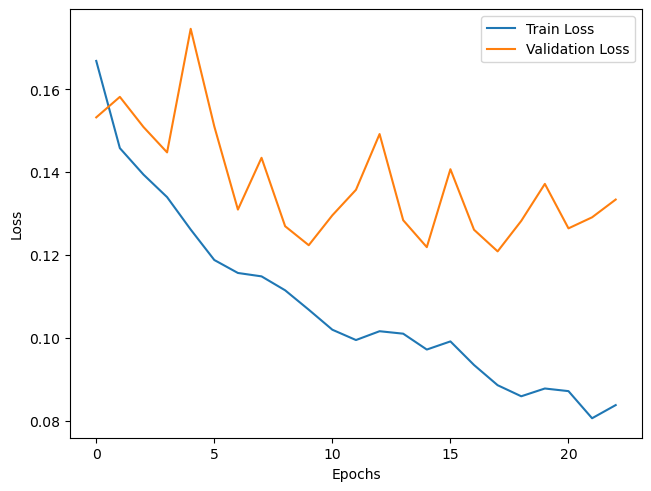

In [15]:
# Load model if it was not trained in this run
if not TRAIN:
    loss_fn = MSE_loss
    model, info = dl.load_model(TransformerEncoder, PATH=f"{MODEL_PATH}/{LOAD_MODEL_NAME}")
    print('Learining rate:', info['learning_rate'])
    summary(model);
    dl.plot_losses(info['train_losses'], info['val_losses'], PATH=PLOT_PATH)

In [16]:
# Compute the test predictions and loss
pos_test_pred_norm, test_loss = tr.test_transformer_model(test_loader, model, loss_fn, device)
pos_test_pred_norm = pos_test_pred_norm.reshape(-1, 2)

if TRAIN:
    print(f"Final Train Loss: {train_losses[-1]:.4f}")
    print(f"Final Validation Loss: {val_losses[-1]:.4f}")
print(f"Final Test Loss: {test_loss:.4f}")

Final Test Loss: 0.1272


In [17]:
# Denormalize the predictions
pos_test_pred = dl.denormalize_labels(pos_test_pred_norm, n_labels=2, means=means, stds=stds)

# Extract the true labels
x_test = test_dataset['xpos'].to_numpy()
y_test = test_dataset['ypos'].to_numpy()
pos_test = np.stack((x_test, y_test), axis=1)

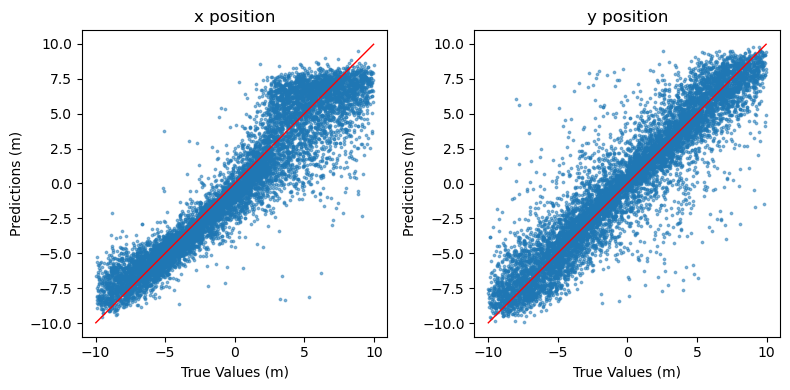

In [18]:
# Plot predicted values vs true values
dl.plot_predicted_vs_true(pos_test, pos_test_pred, n_labels=2, 
                          label_names=['x position', 'y position'], units = ['m', 'm'],
                          PATH=PLOT_PATH);

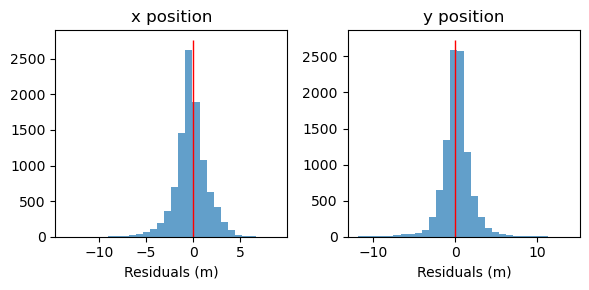

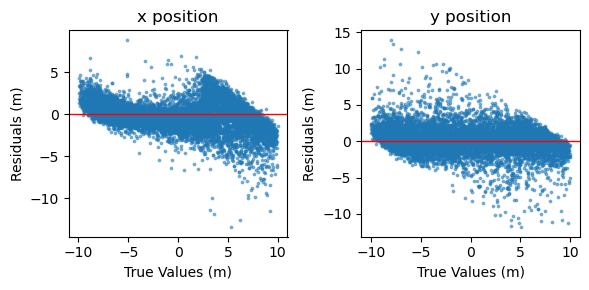

Bias in x position: -0.225 m
Bias in y position: 0.157 m
Std in x position: 1.7 m
Std in y position: 1.84 m


In [19]:
# Plot residuals and calculate bias and std of the predictions
dl.plot_residuals(pos_test, pos_test_pred, n_labels=2, 
                              label_names=['x position', 'y position'], units = ['m', 'm'],
                              PATH=PLOT_PATH)

bias, std = dl.get_bias_std(pos_test, pos_test_pred)
print(f"Bias in x position: {bias[0]:.3g} m")
print(f"Bias in y position: {bias[1]:.3g} m")
print(f"Std in x position: {std[0]:.3g} m")
print(f"Std in y position: {std[1]:.3g} m")

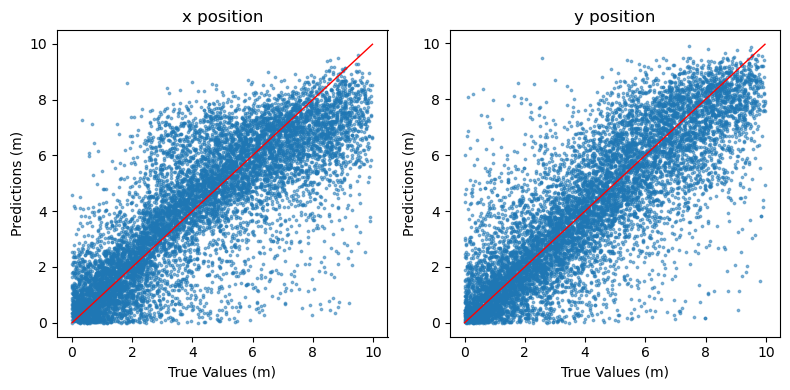

Bias in x position: -0.111 m
Bias in y position: -0.078 m


In [20]:
# Analysis with the absolute values
abs_pos_test = np.abs(pos_test)
abs_pos_test_pred = np.abs(pos_test_pred)

dl.plot_predicted_vs_true(abs_pos_test, abs_pos_test_pred, n_labels=2, 
                          label_names=['x position', 'y position'], units = ['m', 'm'],
                        # PATH='/home/juan-prado/Downloads')
                          PATH=None)

bias, _ = dl.get_bias_std(abs_pos_test, abs_pos_test_pred)

print(f"Bias in x position: {bias[0]:.3g} m")
print(f"Bias in y position: {bias[1]:.3g} m")

In [21]:
lim = 7
mask = (abs_pos_test[:, 0] > lim) | (abs_pos_test[:, 1] > lim)

bias, _ = dl.get_bias_std(abs_pos_test[mask], abs_pos_test_pred[mask])

print(f"Bias in x position: {bias[0]:.3g} m")
print(f"Bias in y position: {bias[1]:.3g} m")

Bias in x position: -0.787 m
Bias in y position: -0.568 m
